# What drives what? Answering questions with basic EDA

**Master in Healthcare Analytics · Session: EDA for "what drives…" questions**
Dataset: Outpatient appointments, Riverbend Community Hospital (fictional), calendar year 2025.

Clinical and operational questions usually arrive in the form *"what drives X?"*: what drives no-shows, what drives waiting times, what drives readmissions. Later in the programme you will answer such questions with statistical models. This session shows how far you can get **without any model**, using only the tools from the previous sessions: group summaries, bar charts, boxplots and two-way tables.

We take two questions:

- **Part A — What drives no-shows?** The outcome is yes/no, so the tool is the *rate by group*.
- **Part B — What drives lead time?** The outcome is a number of days, so the tool is the *median by group*.

The procedure is the same for both: pick a factor, split the appointments by it, summarise the outcome in each group, draw it, and judge how much the outcome moves. Repeat for every factor, then rank them.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

appointments = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/appointments.csv", parse_dates=["booking_date", "appointment_date"])

# For no-show questions: drop cancellations and flag no-shows as 1 / arrived as 0
kept = appointments[appointments["status"].isin(["Arrived", "No-show"])].copy()
kept["no_show"] = (kept["status"] == "No-show").astype(int)

overall_rate = kept["no_show"].mean()
print(f"Appointments kept: {len(kept):,}   overall no-show rate: {overall_rate:.1%}")

Appointments kept: 72,041   overall no-show rate: 14.9%


---
# Part A — What drives no-shows?

## A1. The tool: rate by group

A no-show is either yes or no, so we cannot draw a scatterplot of it or compute a correlation with it in any useful way. What we *can* do is compute the **no-show rate within each group** of a factor and compare the groups. Because we coded no-show as 1 and arrived as 0, the mean of the column *is* the rate, and `groupby().mean()` gives the rate per group in one line.

A small helper draws the chart we will use for every factor: one bar per group, the overall rate as a reference line, and the group sizes underneath so that we never forget how many appointments each bar rests on.

In [2]:
def rate_by(factor, order=None, title=None, xlabel=None):
    """No-show rate per group of `factor`, as a table and a bar chart."""
    g = kept.groupby(factor, observed=True)["no_show"].agg(rate="mean", n="size")
    if order is not None:
        g = g.loc[order]
    fig, ax = plt.subplots()
    labels = [str(idx) + chr(10) + f"n={n:,}" for idx, n in zip(g.index, g["n"])]
    ax.bar(labels, g["rate"] * 100, color=BLUE, width=0.65)
    ax.axhline(overall_rate * 100, color=ORANGE, linestyle="--", linewidth=1.2, label=f"overall {overall_rate:.1%}")
    for i, (rate, n) in enumerate(zip(g["rate"], g["n"])):
        ax.text(i, rate * 100 + 0.6, f"{rate:.1%}", ha="center", fontsize=9, color=INK)
    ax.set_ylabel("No-show rate (%)"); ax.set_ylim(0, max(g["rate"].max() * 100 * 1.25, 20))
    ax.set_title(title or f"No-show rate by {factor}"); ax.set_xlabel(xlabel or "")
    ax.grid(axis="x", visible=False); ax.legend(frameon=False, loc="upper left")
    plt.show()
    return g.assign(rate=(g["rate"] * 100).round(1))

## A2. Categorical factors

Start with the factors that are already groups. For each one, the question is the same: *does the rate move across the groups, and by how much?*

**Visit type.**

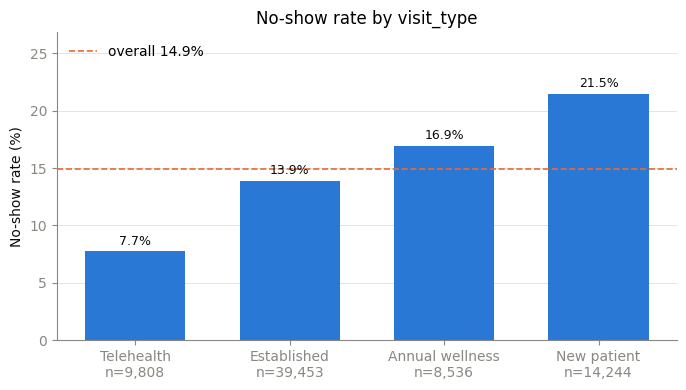

,rate,n
visit_type,,
Telehealth,7.7,9808
Established,13.9,39453
Annual wellness,16.9,8536
New patient,21.5,14244


In [3]:
rate_by("visit_type", order=["Telehealth", "Established", "Annual wellness", "New patient"])

Telehealth visits are missed less than half as often as new-patient visits (8% vs 22%). Two plausible reasons a clinician will think of immediately: no travel is needed for telehealth, and a new patient has no relationship with the clinic yet. The data does not say which; it says the difference is large.

**Clinic.**

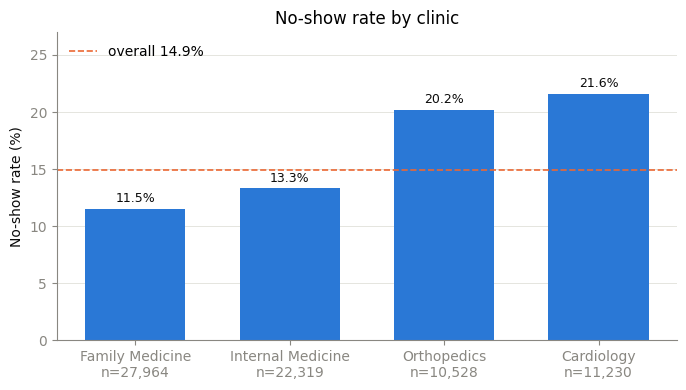

,rate,n
clinic,,
Family Medicine,11.5,27964
Internal Medicine,13.3,22319
Orthopedics,20.2,10528
Cardiology,21.6,11230


In [4]:
rate_by("clinic", order=["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"])

The two specialty clinics have roughly double the no-show rate of Family Medicine. Before concluding that specialty patients are less reliable, remember from the last session that these clinics also have much longer waiting lists; the two things travel together, and one-factor-at-a-time EDA cannot separate them. Keep that in mind for the ranking at the end.

**Primary payer.**

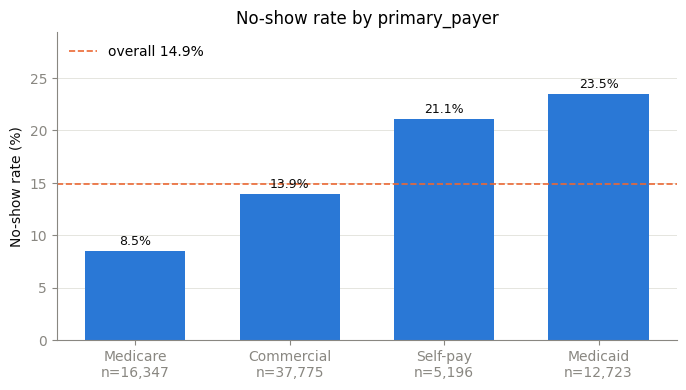

,rate,n
primary_payer,,
Medicare,8.5,16347
Commercial,13.9,37775
Self-pay,21.1,5196
Medicaid,23.5,12723


In [5]:
rate_by("primary_payer", order=["Medicare", "Commercial", "Self-pay", "Medicaid"])

A 15-point spread from Medicare (8.5%) to Medicaid (23.5%). The same caution applies with more force: Medicare patients are almost all over 65, Medicaid patients tend to live farther away and wait longer for appointments. Payer is a label that carries a lot of other things with it.

**Time of day and day of week.**

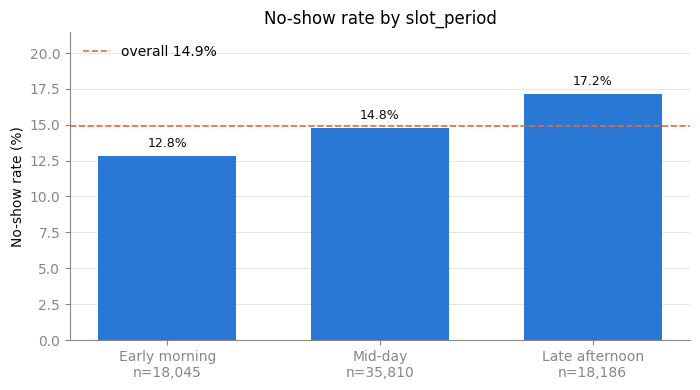

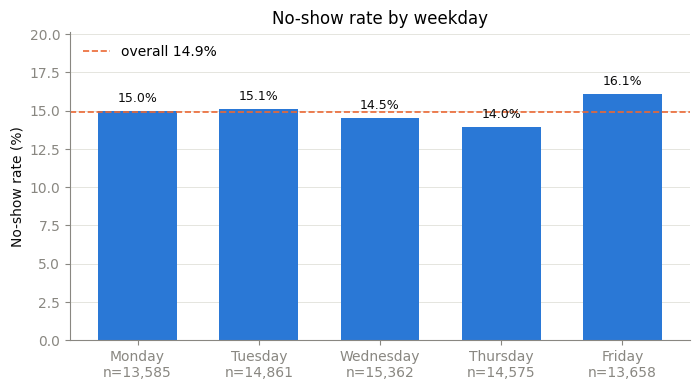

,rate,n
weekday,,
Monday,15.0,13585
Tuesday,15.1,14861
Wednesday,14.5,15362
Thursday,14.0,14575
Friday,16.1,13658


In [6]:
rate_by("slot_period", order=["Early morning", "Mid-day", "Late afternoon"])
rate_by("weekday", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])

Both matter, but modestly: about four points from early morning to late afternoon, and one to two points for Friday. These are the kind of effects that are real, useful for template design, and easy to over-interpret from a single month of data. Here we have a full year and large groups, so the pattern is credible.

**Sex.**

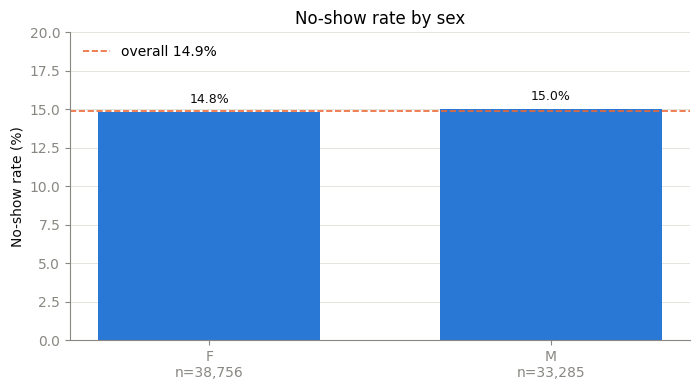

,rate,n
sex,,
F,14.8,38756
M,15.0,33285


In [7]:
rate_by("sex", order=["F", "M"])

One point of difference. This is what *no effect worth reporting* looks like, and it is as important to show as the large effects: a factor that clinicians might expect to matter, and does not.

## A3. Continuous factors: cut into bands first

Lead time, age and distance are numbers, so we cannot group by them directly (there would be one group per distinct value). The trick is to **cut them into bands** with `pd.cut`, then treat the bands as groups. The choice of bands is ours: they should be few enough to read, wide enough to hold many appointments each, and aligned with how the clinic talks ("within a week", "over a month").

**Lead time.**

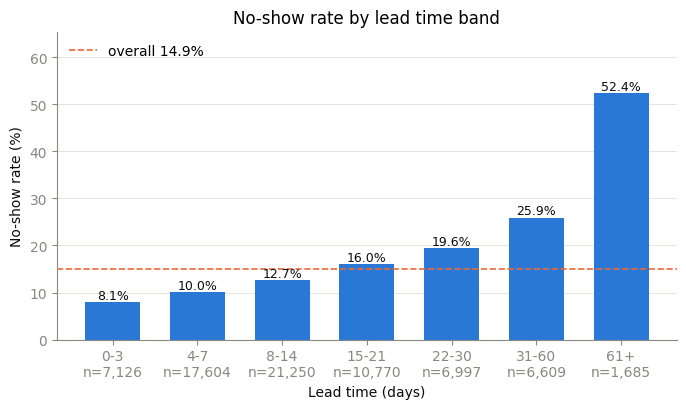

,rate,n
lead_band,,
0-3,8.1,7126
4-7,10.0,17604
8-14,12.7,21250
15-21,16.0,10770
22-30,19.6,6997
31-60,25.9,6609
61+,52.4,1685


In [8]:
kept["lead_band"] = pd.cut(kept["lead_time_days"], bins=[-1, 3, 7, 14, 21, 30, 60, 120],
                           labels=["0-3", "4-7", "8-14", "15-21", "22-30", "31-60", "61+"])
rate_by("lead_band", title="No-show rate by lead time band", xlabel="Lead time (days)")

This is the clearest gradient in the dataset: the rate climbs steadily from 8% for appointments booked within three days to over 50% for those booked more than two months ahead. Every extra band adds a few points. It is also the only factor so far that the clinic can act on directly: shorter lead times are a scheduling decision.

**Prior no-shows.** Already a small whole number, so we only need to group the rare high values together.

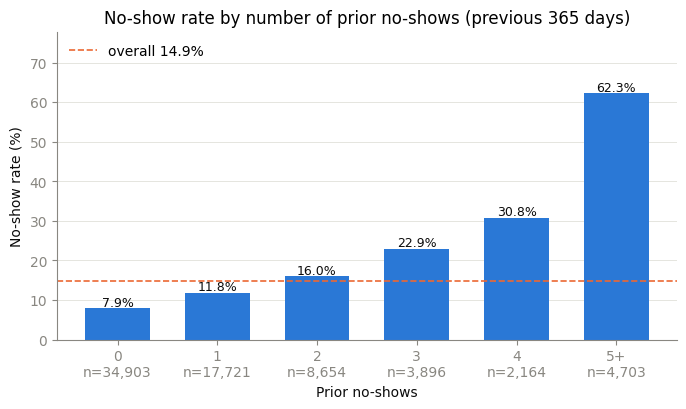

,rate,n
prior_band,,
0,7.9,34903
1,11.8,17721
2,16.0,8654
3,22.9,3896
4,30.8,2164
5+,62.3,4703


In [9]:
kept["prior_band"] = pd.cut(kept["prior_no_shows"], bins=[-1, 0, 1, 2, 3, 4, 100],
                            labels=["0", "1", "2", "3", "4", "5+"])
rate_by("prior_band", title="No-show rate by number of prior no-shows (previous 365 days)", xlabel="Prior no-shows")

The steepest gradient of all: patients with no recent no-shows miss 8% of appointments; those with five or more miss over 60%. History is the best predictor of behaviour, here as in most of healthcare. This factor cannot be changed, but it can be *used*: it tells the clinic who to call.

**Age and distance.**

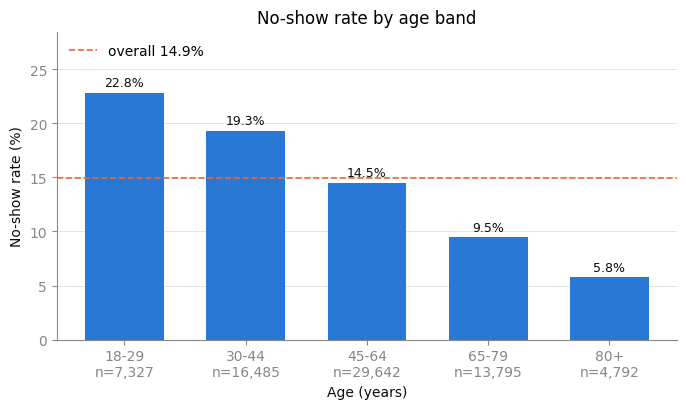

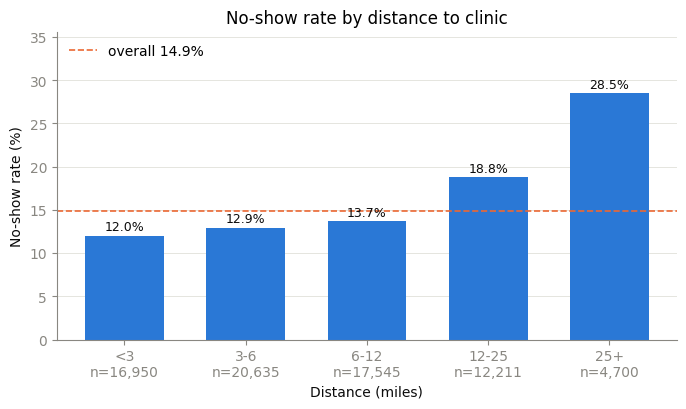

,rate,n
dist_band,,
<3,12.0,16950
3-6,12.9,20635
6-12,13.7,17545
12-25,18.8,12211
25+,28.5,4700


In [10]:
kept["age_band"] = pd.cut(kept["age"], bins=[17, 29, 44, 64, 79, 95], labels=["18-29", "30-44", "45-64", "65-79", "80+"])
kept["dist_band"] = pd.cut(kept["distance_miles"], bins=[0, 3, 6, 12, 25, 80], labels=["<3", "3-6", "6-12", "12-25", "25+"])
rate_by("age_band", title="No-show rate by age band", xlabel="Age (years)")
rate_by("dist_band", title="No-show rate by distance to clinic", xlabel="Distance (miles)")

Both show a steady gradient in the expected direction: younger patients and patients who live farther away miss more. About 17 points end to end for age (6% at 80+ to 23% at 18–29) and 16 for distance, which puts them on a par with payer and ahead of clinic. Note that a gradient across five bands is a different kind of evidence from a gap between two groups: it is harder to produce by accident.

## A4. Two factors at once: a table of rates

Sometimes the question is not "which factor" but "which combination". A **two-way table** of rates (a pivot table) answers it: rows are one factor, columns another, each cell the no-show rate for that combination. Shading the cells turns it into a heatmap that the eye can scan.

In [11]:
two_way = kept.pivot_table(index="clinic", columns="visit_type", values="no_show", aggfunc="mean")
two_way = two_way.loc[["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"],
                      ["Telehealth", "Established", "Annual wellness", "New patient"]]
(two_way * 100).round(1)

visit_type,Telehealth,Established,Annual wellness,New patient
clinic,,,,
Family Medicine,7.3,10.8,12.3,16.8
Internal Medicine,7.3,12.2,15.6,19.2
Orthopedics,11.2,17.8,23.7,27.4
Cardiology,10.0,19.2,24.8,32.4


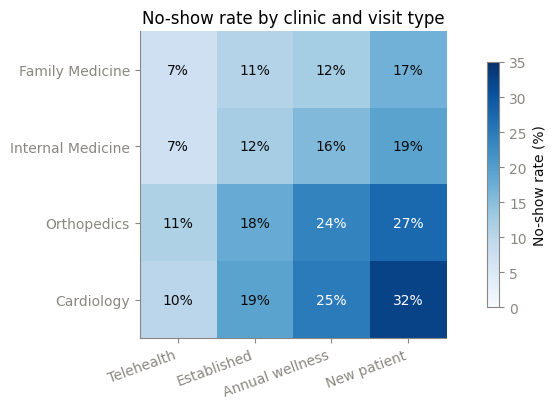

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
im = ax.imshow(two_way * 100, cmap="Blues", vmin=0, vmax=35)
ax.set_xticks(range(two_way.shape[1])); ax.set_xticklabels(two_way.columns, rotation=20, ha="right")
ax.set_yticks(range(two_way.shape[0])); ax.set_yticklabels(two_way.index)
ax.grid(False)
for i in range(two_way.shape[0]):
    for j in range(two_way.shape[1]):
        v = two_way.iloc[i, j] * 100
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=10, color="white" if v > 20 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="No-show rate (%)")
ax.set_title("No-show rate by clinic and visit type")
plt.tight_layout(); plt.show()

Reading across a row, visit type matters within every clinic; reading down a column, clinic matters within every visit type. The two effects **stack**: a telehealth visit in Family Medicine is missed 7% of the time, a new-patient visit in Cardiology 32% of the time. When you meet additive models later, this is the intuition they formalise.

## A5. Ranking the factors

We have now looked at nine factors one at a time. A simple way to rank them is by the **spread of the rate across their groups**: the difference between the highest-rate and lowest-rate group. It is a crude measure (it depends on how we cut the bands and ignores group sizes), but it is honest and it matches what the charts showed.

In [13]:
factors = {"prior_band": "Prior no-shows", "lead_band": "Lead time", "visit_type": "Visit type",
           "primary_payer": "Payer", "clinic": "Clinic", "dist_band": "Distance", "age_band": "Age",
           "slot_period": "Time of day", "weekday": "Weekday", "sex": "Sex"}
rows = []
for col, name in factors.items():
    g = kept.groupby(col, observed=True)["no_show"].mean() * 100
    rows.append({"factor": name, "lowest group": f"{g.idxmin()} ({g.min():.1f}%)",
                 "highest group": f"{g.idxmax()} ({g.max():.1f}%)", "spread (points)": round(g.max() - g.min(), 1)})
ranking = pd.DataFrame(rows).sort_values("spread (points)", ascending=False).reset_index(drop=True)
ranking

,factor,lowest group,highest group,spread (points)
0,Prior no-shows,0 (7.9%),5+ (62.3%),54.4
1,Lead time,0-3 (8.1%),61+ (52.4%),44.3
2,Age,80+ (5.8%),18-29 (22.8%),17.0
3,Distance,<3 (12.0%),25+ (28.5%),16.5
4,Payer,Medicare (8.5%),Medicaid (23.5%),15.0
5,Visit type,Telehealth (7.7%),New patient (21.5%),13.7
6,Clinic,Family Medicine (11.5%),Cardiology (21.6%),10.1
7,Time of day,Early morning (12.8%),Late afternoon (17.2%),4.3
8,Weekday,Thursday (14.0%),Friday (16.1%),2.2
9,Sex,F (14.8%),M (15.0%),0.2


Three tiers emerge. **History and lead time** dominate, with spreads of 40 points or more. **Age, distance, payer, visit type and clinic** form a middle group with spreads of 10–17 points; three of these (payer, clinic, visit type) carry other things with them (waiting time, age, travel), so their true independent contribution is probably smaller than the spread suggests. **Time of day, weekday and sex** are small or nil. The exact order inside the middle group depends on how the bands were cut and should not be over-read.

What this ranking cannot tell you is how much of the payer or clinic effect would remain if lead time were the same everywhere. Separating overlapping factors is precisely what models are for, and it is the reason the next block of the programme exists.

---
# Part B — What drives lead time?

## B1. The tool: median by group

Lead time is a number, so instead of a rate per group we compute a **median per group** (the median, not the mean, because lead time is right-skewed), and we can draw boxplots to see the whole distribution rather than one number. The procedure is otherwise identical: one factor at a time, then a two-way table.

In [14]:
def median_by(factor, order, title=None):
    """Median and P90 lead time per group, plus side-by-side boxplots."""
    g = appointments.groupby(factor, observed=True)["lead_time_days"].agg(median="median", mean="mean", n="size")
    g["P90"] = appointments.groupby(factor, observed=True)["lead_time_days"].quantile(0.9)
    g = g.loc[order]
    fig, ax = plt.subplots()
    ax.boxplot([appointments.loc[appointments[factor] == v, "lead_time_days"] for v in order],
               tick_labels=[str(v) for v in order], widths=0.5, showfliers=False,
               medianprops=dict(color=ORANGE, linewidth=1.5), boxprops=dict(color=BLUE),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    for i, m in enumerate(g["median"]):
        ax.text(i + 1.3, m, f"{m:.0f} d", va="center", fontsize=9, color=INK)
    ax.set_ylabel("Lead time (days)"); ax.set_title(title or f"Lead time by {factor} (outliers hidden)")
    ax.grid(axis="x", visible=False)
    plt.show()
    return g.round(1)

**Clinic.**

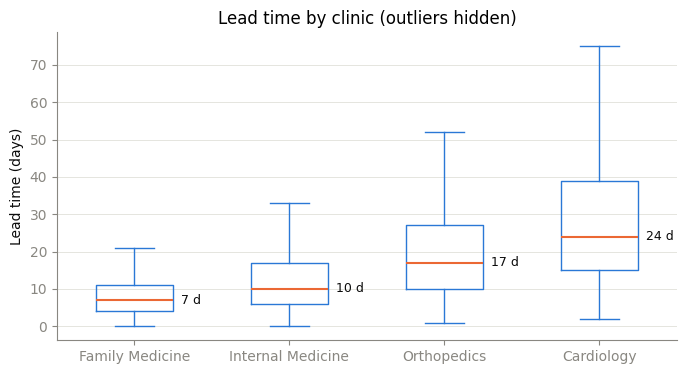

,median,mean,n,P90
clinic,,,,
Family Medicine,7.0,9.0,30563,18.0
Internal Medicine,10.0,13.7,24540,27.0
Orthopedics,17.0,21.5,11622,41.0
Cardiology,24.0,30.7,12528,61.0


In [15]:
median_by("clinic", ["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"])

**Visit type.**

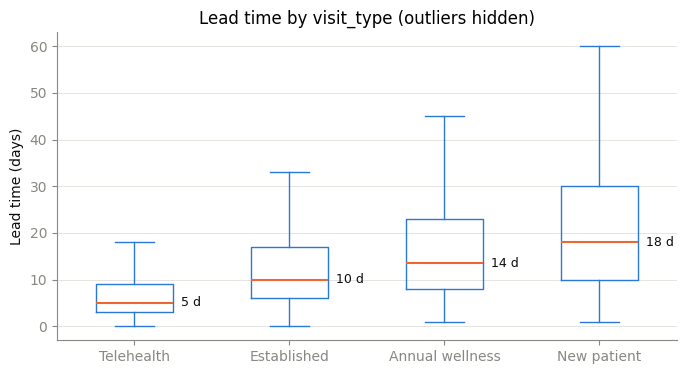

,median,mean,n,P90
visit_type,,,,
Telehealth,5.0,7.0,10724,14.0
Established,10.0,14.1,43233,29.0
Annual wellness,13.5,18.7,9476,38.0
New patient,18.0,24.3,15820,51.0


In [16]:
median_by("visit_type", ["Telehealth", "Established", "Annual wellness", "New patient"])

**Payer.**

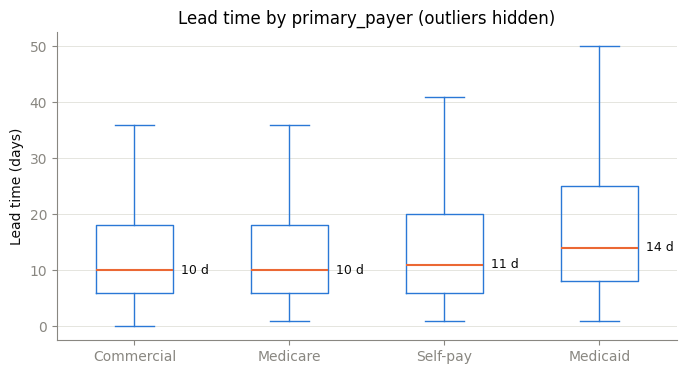

,median,mean,n,P90
primary_payer,,,,
Commercial,10.0,14.7,41526,31.0
Medicare,10.0,14.7,17954,31.0
Self-pay,11.0,16.0,5726,35.0
Medicaid,14.0,20.0,14047,43.0


In [17]:
median_by("primary_payer", ["Commercial", "Medicare", "Self-pay", "Medicaid"])

Clinic is the dominant driver (median 7 → 24 days), visit type second (5 → 18), and payer a smaller but real effect: Medicaid patients wait a median of four days longer than commercially insured ones. That last finding deserves a clinical pause. Nothing about insurance should change how long a patient waits for an appointment; if it does, something in the referral or booking process is treating these patients differently.

## B2. Two factors at once: a table of medians

In [18]:
lead_two_way = appointments.pivot_table(index="clinic", columns="visit_type", values="lead_time_days", aggfunc="median")
lead_two_way = lead_two_way.loc[["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"],
                                ["Telehealth", "Established", "Annual wellness", "New patient"]]
lead_two_way.astype(int)

visit_type,Telehealth,Established,Annual wellness,New patient
clinic,,,,
Family Medicine,4,6,9,11
Internal Medicine,6,10,13,18
Orthopedics,9,15,20,27
Cardiology,13,21,30,39


The effects stack here too: a telehealth visit in Family Medicine has a median lead time of 4 days, a new-patient visit in Cardiology 39 days, a ten-fold difference. Every cell in between is roughly "clinic effect plus visit-type effect". If a manager asks *where* the long waits are, this table is the answer: new-patient and annual-wellness visits in the two specialty clinics.

## B3. Factors that do not drive lead time

For completeness, the factors that do not: weekday, time of day, sex, and age have medians within a day or two of each other. Distance too. Lead time is a property of the clinic's booking process, not of the patient.

In [19]:
for col in ["weekday", "slot_period", "sex"]:
    print(appointments.groupby(col)["lead_time_days"].median().round(1).to_dict())

{'Friday': 11.0, 'Monday': 11.0, 'Thursday': 11.0, 'Tuesday': 11.0, 'Wednesday': 11.0}
{'Early morning': 11.0, 'Late afternoon': 11.0, 'Mid-day': 11.0}
{'F': 11.0, 'M': 11.0}


---
# Summary: what we learned, and what we could not

| Question | Tool | Strongest drivers | Modest | None |
|---|---|---|---|---|
| What drives no-shows? | rate by group (bands for continuous factors); two-way rate table | prior no-shows, lead time | age, distance, payer, visit type, clinic; time of day (small) | sex, weekday |
| What drives lead time? | median by group with boxplots; two-way median table | clinic, visit type | payer | weekday, time of day, sex, age, distance |

Of the drivers of no-shows, only **lead time** is directly under the clinic's control, and lead time is itself driven by clinic and visit type. That chain (booking process → waiting time → attendance) is the operational story the data tells, and it was found with nothing more than group summaries and bar charts.

**What basic EDA could not do.** Several factors overlap: specialty clinics have long lead times; Medicaid patients have long lead times and live farther away; Medicare patients are older. One-factor-at-a-time analysis shows each raw association but cannot say how much of the clinic or payer effect is really a lead-time effect. Answering that requires holding other factors constant, which is what statistical models are for. You now know the questions to ask them.